## 0. Cài đặt thư viện

In [ ]:
# Cài đặt TabNet
!pip install pytorch-tabnet -q
!pip install kaggle -q

In [ ]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print(' Import thư viện thành công!')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')

 Import thư viện thành công!
PyTorch version: 2.11.0+cu128
GPU available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Tải & Khám sát dữ liệu ban đầu

In [ ]:


# Đọc dữ liệu
df = pd.read_csv('/content/drive/MyDrive/hotel_bookings.csv')
print('=' * 50)
print('THÔNG TIN TỔNG QUAN VỀ DATASET')
print('=' * 50)
print(f'Số dòng:    {df.shape[0]:,}')
print(f'Số cột:     {df.shape[1]}')
print(f'\nPhân phối biến mục tiêu (is_canceled):')
print(df['is_canceled'].value_counts())
print(f'\nTỉ lệ hủy: {df["is_canceled"].mean()*100:.1f}%')

THÔNG TIN TỔNG QUAN VỀ DATASET
Số dòng:    119,390
Số cột:     32

Phân phối biến mục tiêu (is_canceled):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Tỉ lệ hủy: 37.0%


In [ ]:
# Xem 5 dòng đầu
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# Thông tin kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Thống kê mô tả
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


---
## 2. Tiền xử lý dữ liệu (Preprocessing)
### 2.1 Xử lý Missing Values

### Tương quan với biến mục tiêu trước xử lý Missing Values

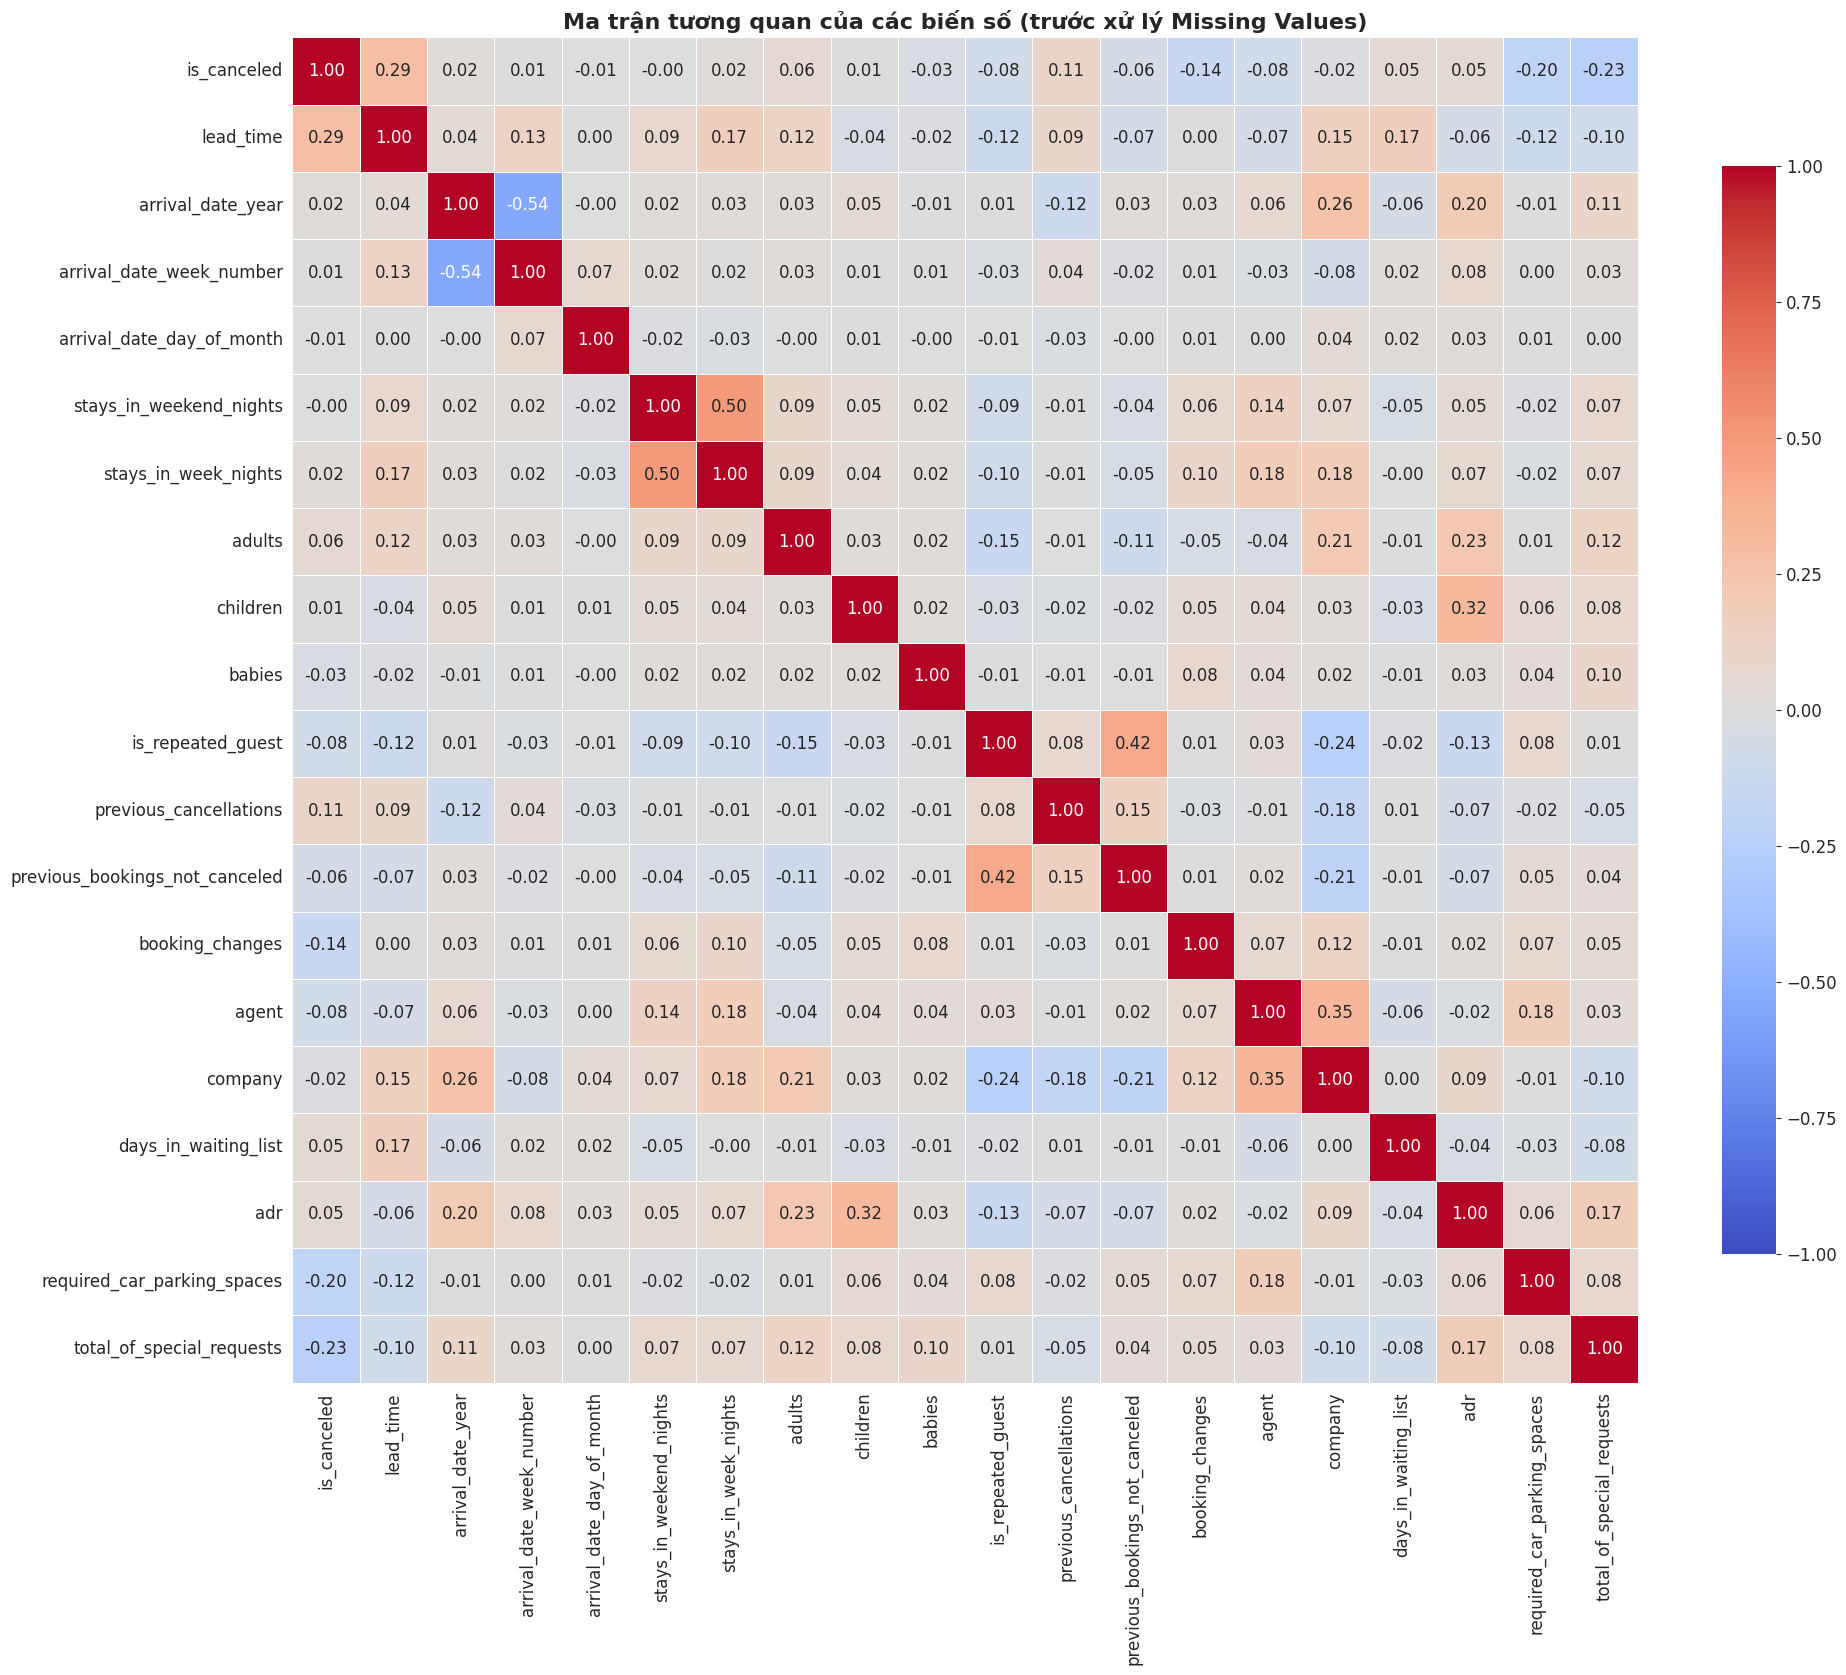

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chọn các cột số từ DataFrame gốc df
original_num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Tính ma trận tương quan
corr_matrix_full = df[original_num_cols].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(
    corr_matrix_full,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True, # Đảm bảo các ô là hình vuông
    linewidths=.5, # Thêm đường kẻ giữa các ô
    cbar_kws={'shrink': .7} # Điều chỉnh kích thước thanh màu
)
plt.title('Ma trận tương quan của các biến số (trước xử lý Missing Values)', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Các cột có giá trị bị thiếu:')
print(missing_df[missing_df['Missing Count'] > 0])

Các cột có giá trị bị thiếu:
          Missing Count  Missing (%)
company          112593    94.306893
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


1. cột Children điền 0: một booking để trống phần trẻ em thì có nghĩa là không có trẻ em đi cùng.
2. Country điền mode: vì là tên quốc gia và tỉ lệ thiếu quá nhỏ nên có vấn đề gì .
3. agent điền 0 : vì null có thể do khách không booking qua đại lí và vì tỉ lệ missing lớn nên điền 0.
4. company : cũng giống agent là khách đặt qua công ti nên điền 0 ko qua công ty là hợp lý
5. loại bỏ các cột trùng lặp

=====> Dữ liệu sạch hơn: Các lỗi logic và đã loại bỏ giá trị ngoại lai, giúp mô hình dự báo chính xác hơn, không bị học nhiễu.

In [ ]:
df_clean = df.copy()

df_clean['children'] = df_clean['children'].fillna(0).astype(int)
df_clean['country']  = df_clean['country'].fillna(df_clean['country'].mode()[0])
df_clean['agent']    = df_clean['agent'].fillna(0).astype(int)
df_clean['company']  = df_clean['company'].fillna(0).astype(int)

print('Sau khi xử lý missing values:')
print(f'Tổng missing còn lại: {df_clean.isnull().sum().sum()}')
print(' Đã xử lý xong Missing Values!')

Sau khi xử lý missing values:
Tổng missing còn lại: 0
 Đã xử lý xong Missing Values!


### 2.2 Xử lý dữ liệu trùng lặp

- làm cho dữ liệu sạch không có dữ liệu trùng lặp tránh bị byass

In [ ]:
# Kiểm tra và xử lý dữ liệu trùng lặp
before_duplicates = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after_duplicates = len(df_clean)

print(f'Số dòng trùng lặp đã xóa: {before_duplicates - after_duplicates:,}')
print(f'Số dòng còn lại sau khi xử lý trùng lặp: {after_duplicates:,}')
print('✅ Đã xử lý xong dữ liệu trùng lặp!')

Số dòng trùng lặp đã xóa: 32,013
Số dòng còn lại sau khi xử lý trùng lặp: 87,377
✅ Đã xử lý xong dữ liệu trùng lặp!


### 2.3 Xử lý Outliers

1.vẽ Boxplot phát hiện nhanh dữ liệu ngoại lai (Outliers)

2.Dữ liệu đang bị lệch phải cực kỳ mạnh->>buộc phải lọc bỏ các chấm đen nằm ngoài đường râu này để mô hình toán không bị kéo lệch và mạng nơ-ron không bị bùng nổ.

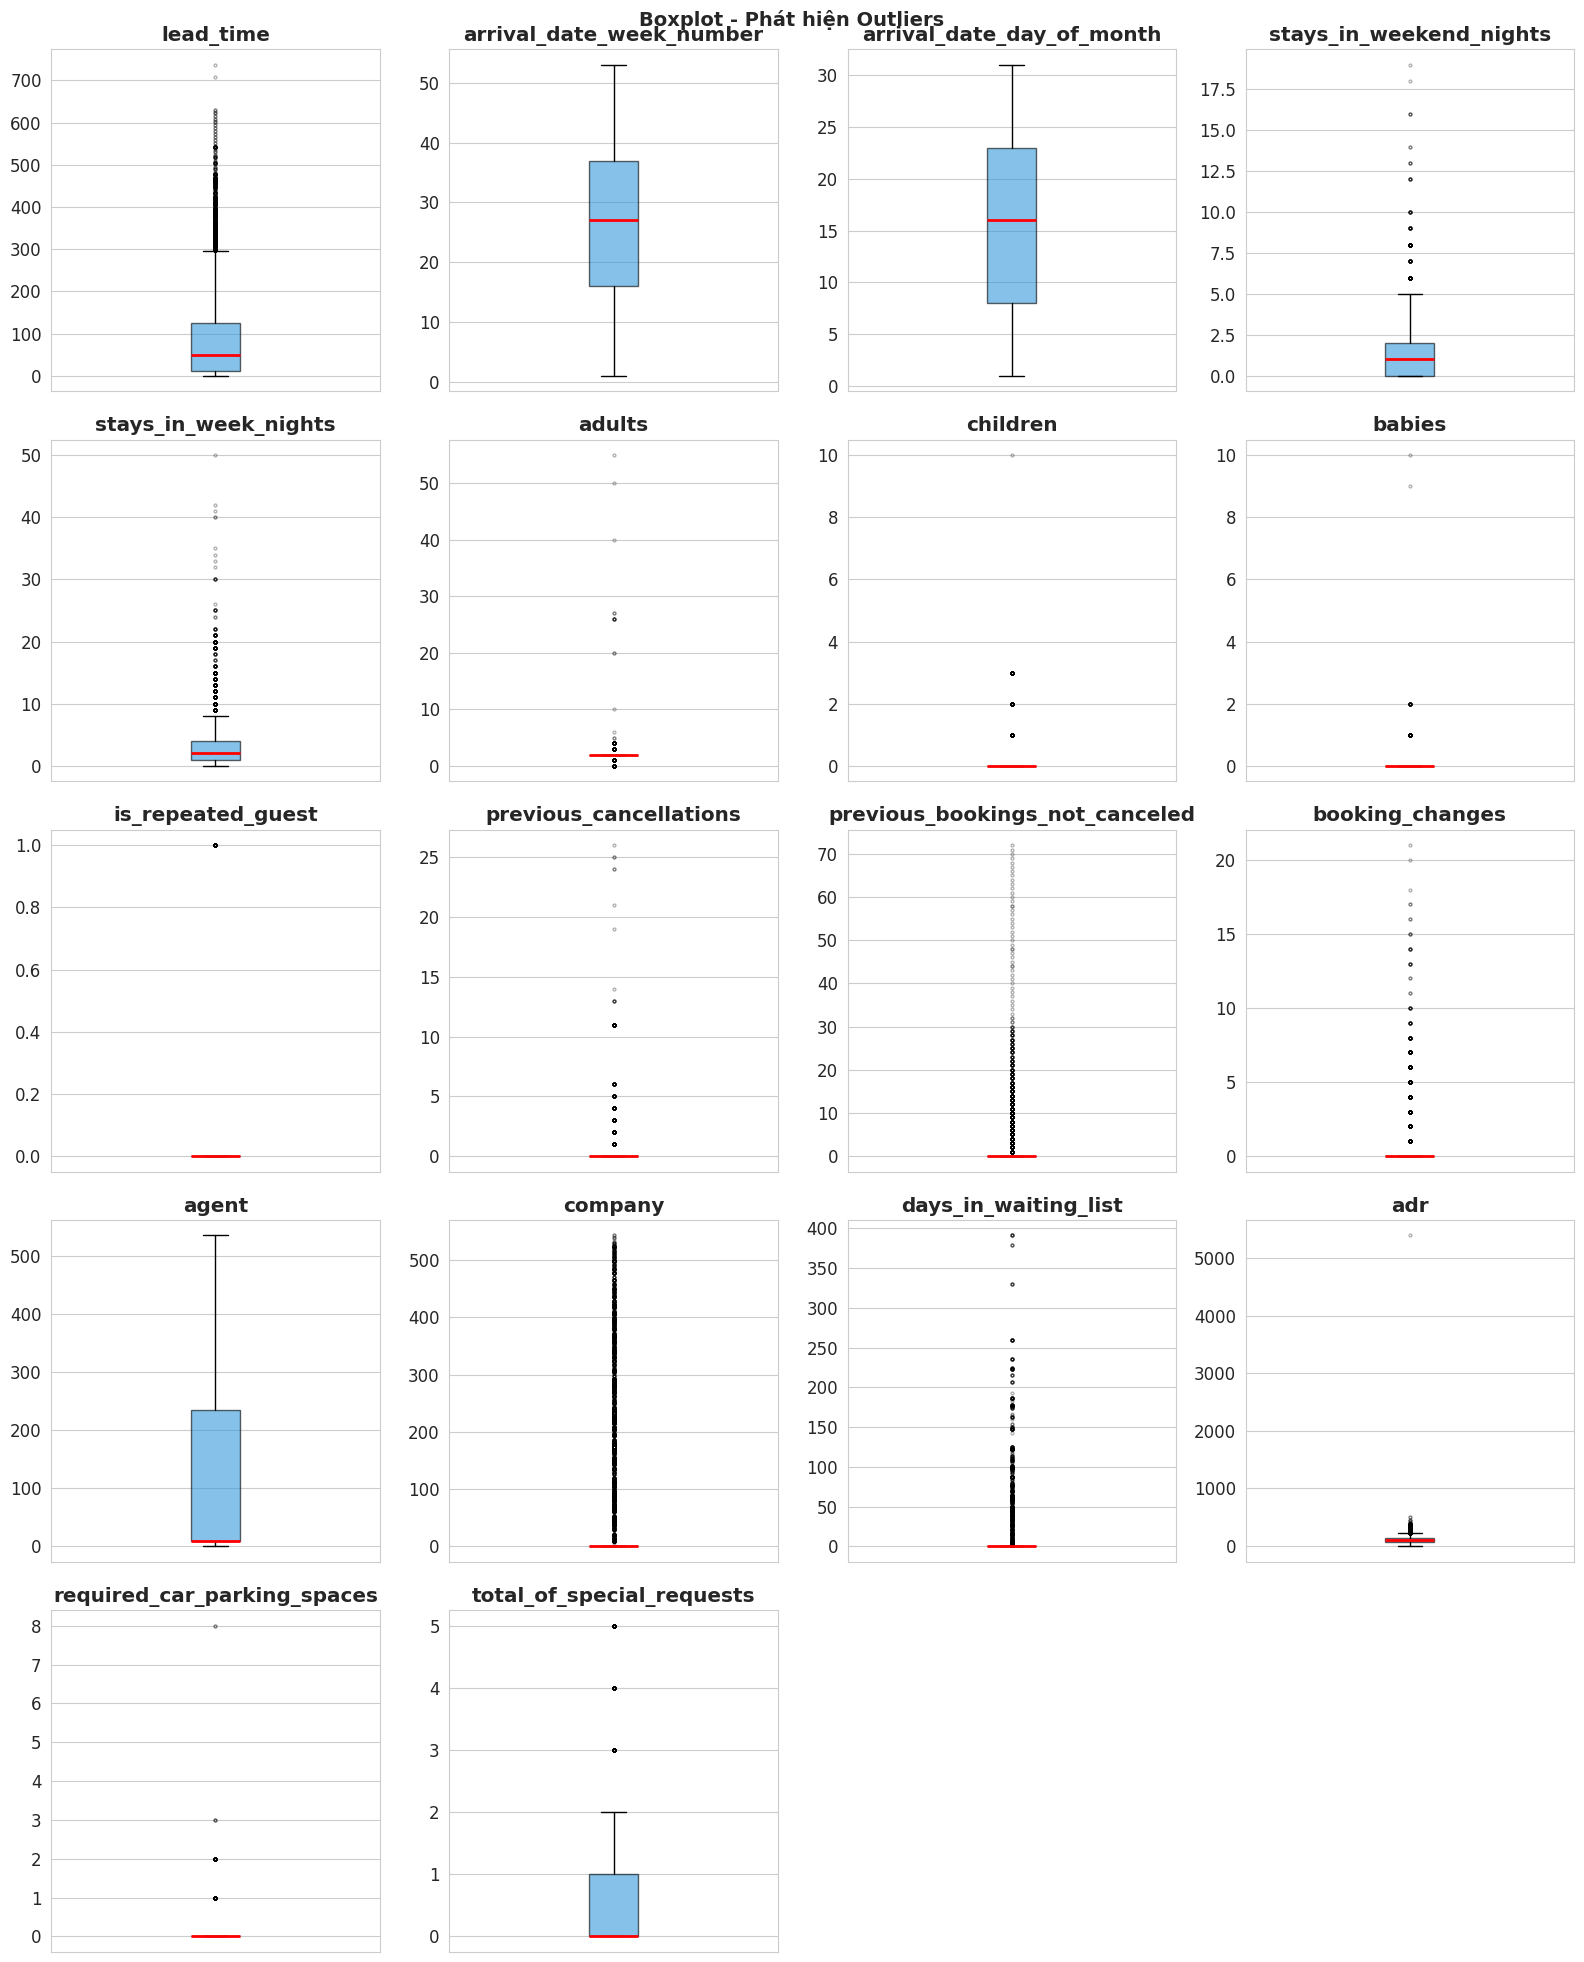

In [ ]:
num_cols_plot = [c for c in df_clean.select_dtypes(include='number').columns
                 if c not in ['is_canceled', 'arrival_date_year']]

ncols = 4
nrows = -(-len(num_cols_plot) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    axes[i].boxplot(df_clean[col].dropna(),
                    patch_artist=True,           # tô màu box
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([])                       # ẩn trục x số 1 vô nghĩa

for j in range(i + 1, len(axes)):               # ẩn ô thừa
    axes[j].set_visible(False)

plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý outliers bằng phương pháp IQR
def remove_outliers_iqr(df, col, factor=3.0):
    """
    Loại bỏ outliers dùng IQR với factor lớn (3.0) để chỉ xóa outliers cực đoan.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = len(df)
    print(f'  {col}: xóa {before - after:,} dòng outlier (còn {after:,} dòng)')
    return df

print('Xử lý outliers:')
# adr có outlier cực đoan (>5000$)
df_clean = remove_outliers_iqr(df_clean, 'adr', factor=3.0)
# lead_time: loại booking trước quá xa (>700 ngày)
df_clean = remove_outliers_iqr(df_clean, 'lead_time', factor=3.0)

# Xóa dòng không hợp lệ: adults=0, children=0, babies=0 (không có khách)
before = len(df_clean)
df_clean = df_clean[~((df_clean['adults'] == 0) &
                       (df_clean['children'] == 0) &
                       (df_clean['babies'] == 0))]
print(f'  Dòng không có khách: xóa {before - len(df_clean)} dòng')

# Xóa adr âm
before = len(df_clean)
df_clean = df_clean[df_clean['adr'] >= 0]
print(f'  adr âm: xóa {before - len(df_clean)} dòng')

print(f'\nSau xử lý outliers: {len(df_clean):,} dòng (từ {len(df):,} dòng ban đầu)')
print(' Đã xử lý xong Outliers!')

Xử lý outliers:
  adr: xóa 136 dòng outlier (còn 87,241 dòng)
  lead_time: xóa 132 dòng outlier (còn 87,109 dòng)
  Dòng không có khách: xóa 166 dòng
  adr âm: xóa 1 dòng

Sau xử lý outliers: 86,942 dòng (từ 119,390 dòng ban đầu)
 Đã xử lý xong Outliers!


### 2.4 Mã hóa dữ liệu (Encoding)

1. Tự động tách tập dữ liệu thành 2 nhóm riêng biệt: nhóm các cột dạng chữ  và nhóm các cột dạng số.

2. Được dùng để tính toán trực tiếp, nhưng vì lệch thang đo nên sẽ được xử lý bằng StandardScaler ở các cell sau.

3. ta bắt buộc phải dùng LabelEncoder phối hợp với các tầng Embedding Layer của TabNet để nén dữ liệu lại thành các vector không gian, giúp mô hình học sâu hiểu được bản chất.

Đã đưa các cột về chung một thang đo mean=0, độ lệch chuẩn về =1.

In [ ]:
# Xác định các cột categorical và numerical
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'is_canceled']

print(f'Cột categorical ({len(cat_cols)}): {cat_cols}')
print(f'\nCột numerical ({len(num_cols)}): {num_cols}')

Cột categorical (12): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Cột numerical (19): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [ ]:
# Label Encoding cho các cột categorical
# (TabNet xử lý tốt với Label Encoding + embedding)
df_encoded = df_clean.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {len(le.classes_)} giá trị duy nhất')

print('\n Đã mã hóa xong các cột categorical!')

  hotel: 2 giá trị duy nhất
  arrival_date_month: 12 giá trị duy nhất
  meal: 5 giá trị duy nhất
  country: 177 giá trị duy nhất
  market_segment: 8 giá trị duy nhất
  distribution_channel: 5 giá trị duy nhất
  reserved_room_type: 9 giá trị duy nhất
  assigned_room_type: 11 giá trị duy nhất
  deposit_type: 3 giá trị duy nhất
  customer_type: 4 giá trị duy nhất
  reservation_status: 3 giá trị duy nhất
  reservation_status_date: 926 giá trị duy nhất

 Đã mã hóa xong các cột categorical!


### 2.4 Chuẩn hóa dữ liệu (Scaling)

1. thêm một số cột  hữu ích
2. chuẩn bị dữ liệu cho mô hình học
3. Xóa cột rò rỉ : Loại bỏ ngay cột trạng thái hiện tại (reservation_status) và ngày cập nhật trạng thái, vì giữ lại các cột biết trước kết quả này sẽ làm mô hình bị "học lỏm" và mất đi khả năng dự báo trong thực tế.

In [ ]:
import numpy as np

# 1. TỰ ĐỘNG PHÂN LOẠI DANH SÁCH CỘT THEO KIỂU DỮ LIỆU (KHÔNG DÙNG TÊN CỨNG)
cat_cols = [col for col in df_encoded.columns if df_encoded[col].dtype == 'object' or df_encoded[col].dtype.name == 'category']
num_cols = [col for col in df_encoded.columns if df_encoded[col].dtype in ['int64', 'float64']]

# 2. TỰ ĐỘNG ĐỊNH VỊ CÁC NHÓM CỘT DỰA TRÊN TỪ KHÓA
stay_dependencies = [col for col in df_encoded.columns if 'night' in col.lower()]

guest_keywords = ['adult', 'child', 'baby']
guest_dependencies = [col for col in df_encoded.columns if any(kw in col.lower() for kw in guest_keywords)]

adr_candidates = [col for col in df_encoded.columns if 'adr' in col.lower() or 'rate' in col.lower()]
adr_col = adr_candidates[0] if adr_candidates else None

target_candidates = [col for col in df_encoded.columns if 'cancel' in col.lower()]
TARGET_COL = target_candidates[0] if target_candidates else None

LEAKAGE_COLS = [col for col in df_encoded.columns if 'status' in col.lower()]

# 3. TIẾN HÀNH TẠO THÊM ĐẶC TRƯNG MỚI (TỰ ĐỘNG ĐẶT TÊN BIẾN THEO CHUẨN ĐẦU RA)
if stay_dependencies:
    df_encoded['total_stays'] = df_encoded[stay_dependencies].sum(axis=1)
else:
    df_encoded['total_stays'] = 0

if guest_dependencies:
    df_encoded['total_guests'] = df_encoded[guest_dependencies].sum(axis=1)
else:
    df_encoded['total_guests'] = 0

if adr_col and 'total_stays' in df_encoded.columns:
    df_encoded['total_cost'] = df_encoded[adr_col] * df_encoded['total_stays']
else:
    df_encoded['total_cost'] = 0

# 4. CẬP NHẬT LẠI DANH SÁCH CỘT SỐ VÀ LỌC ĐỘNG TẬP TÍNH NĂNG X, Y
new_features = ['total_stays', 'total_guests', 'total_cost']
created_features = [col for col in new_features if col in df_encoded.columns]
num_cols_updated = [col for col in num_cols if col not in created_features] + created_features

all_potential_cols = cat_cols + num_cols_updated

feature_cols = [
    col for col in all_potential_cols
    if col in df_encoded.columns and col not in LEAKAGE_COLS and col != TARGET_COL
]

# 5. TRÍCH XUẤT ĐẦU RA CUỐI CÙNG CHO CÁC CELL SAU SỬ DỤNG
X = df_encoded[feature_cols].copy()

if TARGET_COL:
    y = df_encoded[TARGET_COL].values
else:
    raise KeyError()

1. Chuẩn hóa dữ liệu số (StandardScaler): Ép tất cả các cột số về cùng phân phối chuẩn (Trung bình = 0, Phương sai = 1) để sửa triệt để lỗi lệch phải và bùng nổ gradient đã phát hiện từ biểu đồ trước đó.

In [ ]:

from sklearn.preprocessing import StandardScaler
import numpy as np
feature_cols = list(X.columns)


scaler = StandardScaler()
num_cols_to_scale = [col for col in num_cols_updated if col in feature_cols]
X[num_cols_to_scale] = scaler.fit_transform(X[num_cols_to_scale])

print(' Đã chuẩn hóa xong dữ liệu số theo cấu trúc đồng bộ!')
print(f'Thứ tự danh sách {len(feature_cols)} đặc trưng đầu vào:')
print(feature_cols)

 Đã chuẩn hóa xong dữ liệu số theo cấu trúc đồng bộ!
Thứ tự danh sách 32 đặc trưng đầu vào:
['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stays', 'total_guests', 'total_cost']


1. Định vị vị trí cột chữ và dùng công thức căn bậc hai để tự động tính toán số chiều Vector nhúng (Embedding), giúp mạng nơ-ron học sâu xử lý được các cột nhiều chữ như quốc gia (country).

In [ ]:
# --- CELL MỚI: TÍNH TOÁN CAT_IDXS, CAT_DIMS VÀ EMBEDDING DIM ---
cat_idxs = []
cat_dims = []

# Tìm vị trí (index) của các cột phân loại trong danh sách feature_cols
for idx, col in enumerate(feature_cols):
    if col in cat_cols:
        cat_idxs.append(idx)
        # Số lượng nhóm duy nhất của cột đó (được lưu từ LabelEncoder trước đó)
        cat_dims.append(len(label_encoders[col].classes_))

# Tính toán số chiều cho vector nhúng (embedding dimension) dựa trên quy tắc căn bậc hai
cat_emb_dim = [min(16, int(np.sqrt(dim))) for dim in cat_dims]

print("Vị trí các cột phân loại (cat_idxs):", cat_idxs)
print("Số lượng nhóm tương ứng (cat_dims):", cat_dims)
print("Số chiều Vector nhúng tương ứng (cat_emb_dim):", cat_emb_dim)

Vị trí các cột phân loại (cat_idxs): []
Số lượng nhóm tương ứng (cat_dims): []
Số chiều Vector nhúng tương ứng (cat_emb_dim): []


1. chia dữ liệu theo tỷ lệ 70% Train / 15% Valid / 15% Test, đảm bảo mảng số và mảng nhãn trùng khớp hoàn hảo từng dòng, giúp TabNet không bị báo lỗi so lệch khi huấn luyện.

In [ ]:

from sklearn.model_selection import train_test_split
import numpy as np

# 1. Đảm bảo X và y lấy chung từ một DataFrame đã đồng bộ hóa sau khi tiền xử lý
# (Loại bỏ cột mục tiêu và cột rò rỉ thông tin 'reservation_status' nếu có)
feature_cols = [col for col in feature_cols if col in df_encoded.columns and col != 'is_canceled']

# Lấy dữ liệu dưới dạng mảng Numpy trực tiếp từ cùng một DataFrame sạch
X_data = df_encoded[feature_cols].values.astype(np.float32)
y_data = df_encoded['is_canceled'].values

# 2. Thực hiện chia tập dữ liệu: Train (70%), Validation (15%), Test (15%)
X_temp, X_test_np, y_temp, y_test = train_test_split(
    X_data, y_data, test_size=0.15, random_state=42, stratify=y_data
)

# Chia tiếp tập Temp thành Train và Validation
X_train_np, X_val_np, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(' Sửa lỗi thành công! Kiểm tra số lượng dòng dữ liệu đã đồng bộ:')
print(f' - Tập Train: X_train_np = {X_train_np.shape[0]:,} dòng | y_train = {len(y_train):,} dòng')
print(f' - Tập Valid: X_val_np   = {X_val_np.shape[0]:,} dòng | y_val   = {len(y_val):,} dòng')
print(f' - Tập Test : X_test_np  = {X_test_np.shape[0]:,} dòng | y_test  = {len(y_test):,} dòng')

 Sửa lỗi thành công! Kiểm tra số lượng dòng dữ liệu đã đồng bộ:
 - Tập Train: X_train_np = 60,856 dòng | y_train = 60,856 dòng
 - Tập Valid: X_val_np   = 13,044 dòng | y_val   = 13,044 dòng
 - Tập Test : X_test_np  = 13,042 dòng | y_test  = 13,042 dòng


---
## 3. Phân tích dữ liệu khám phá (EDA)
### 3.1 Phân tích tương quan (Correlation Analysis)

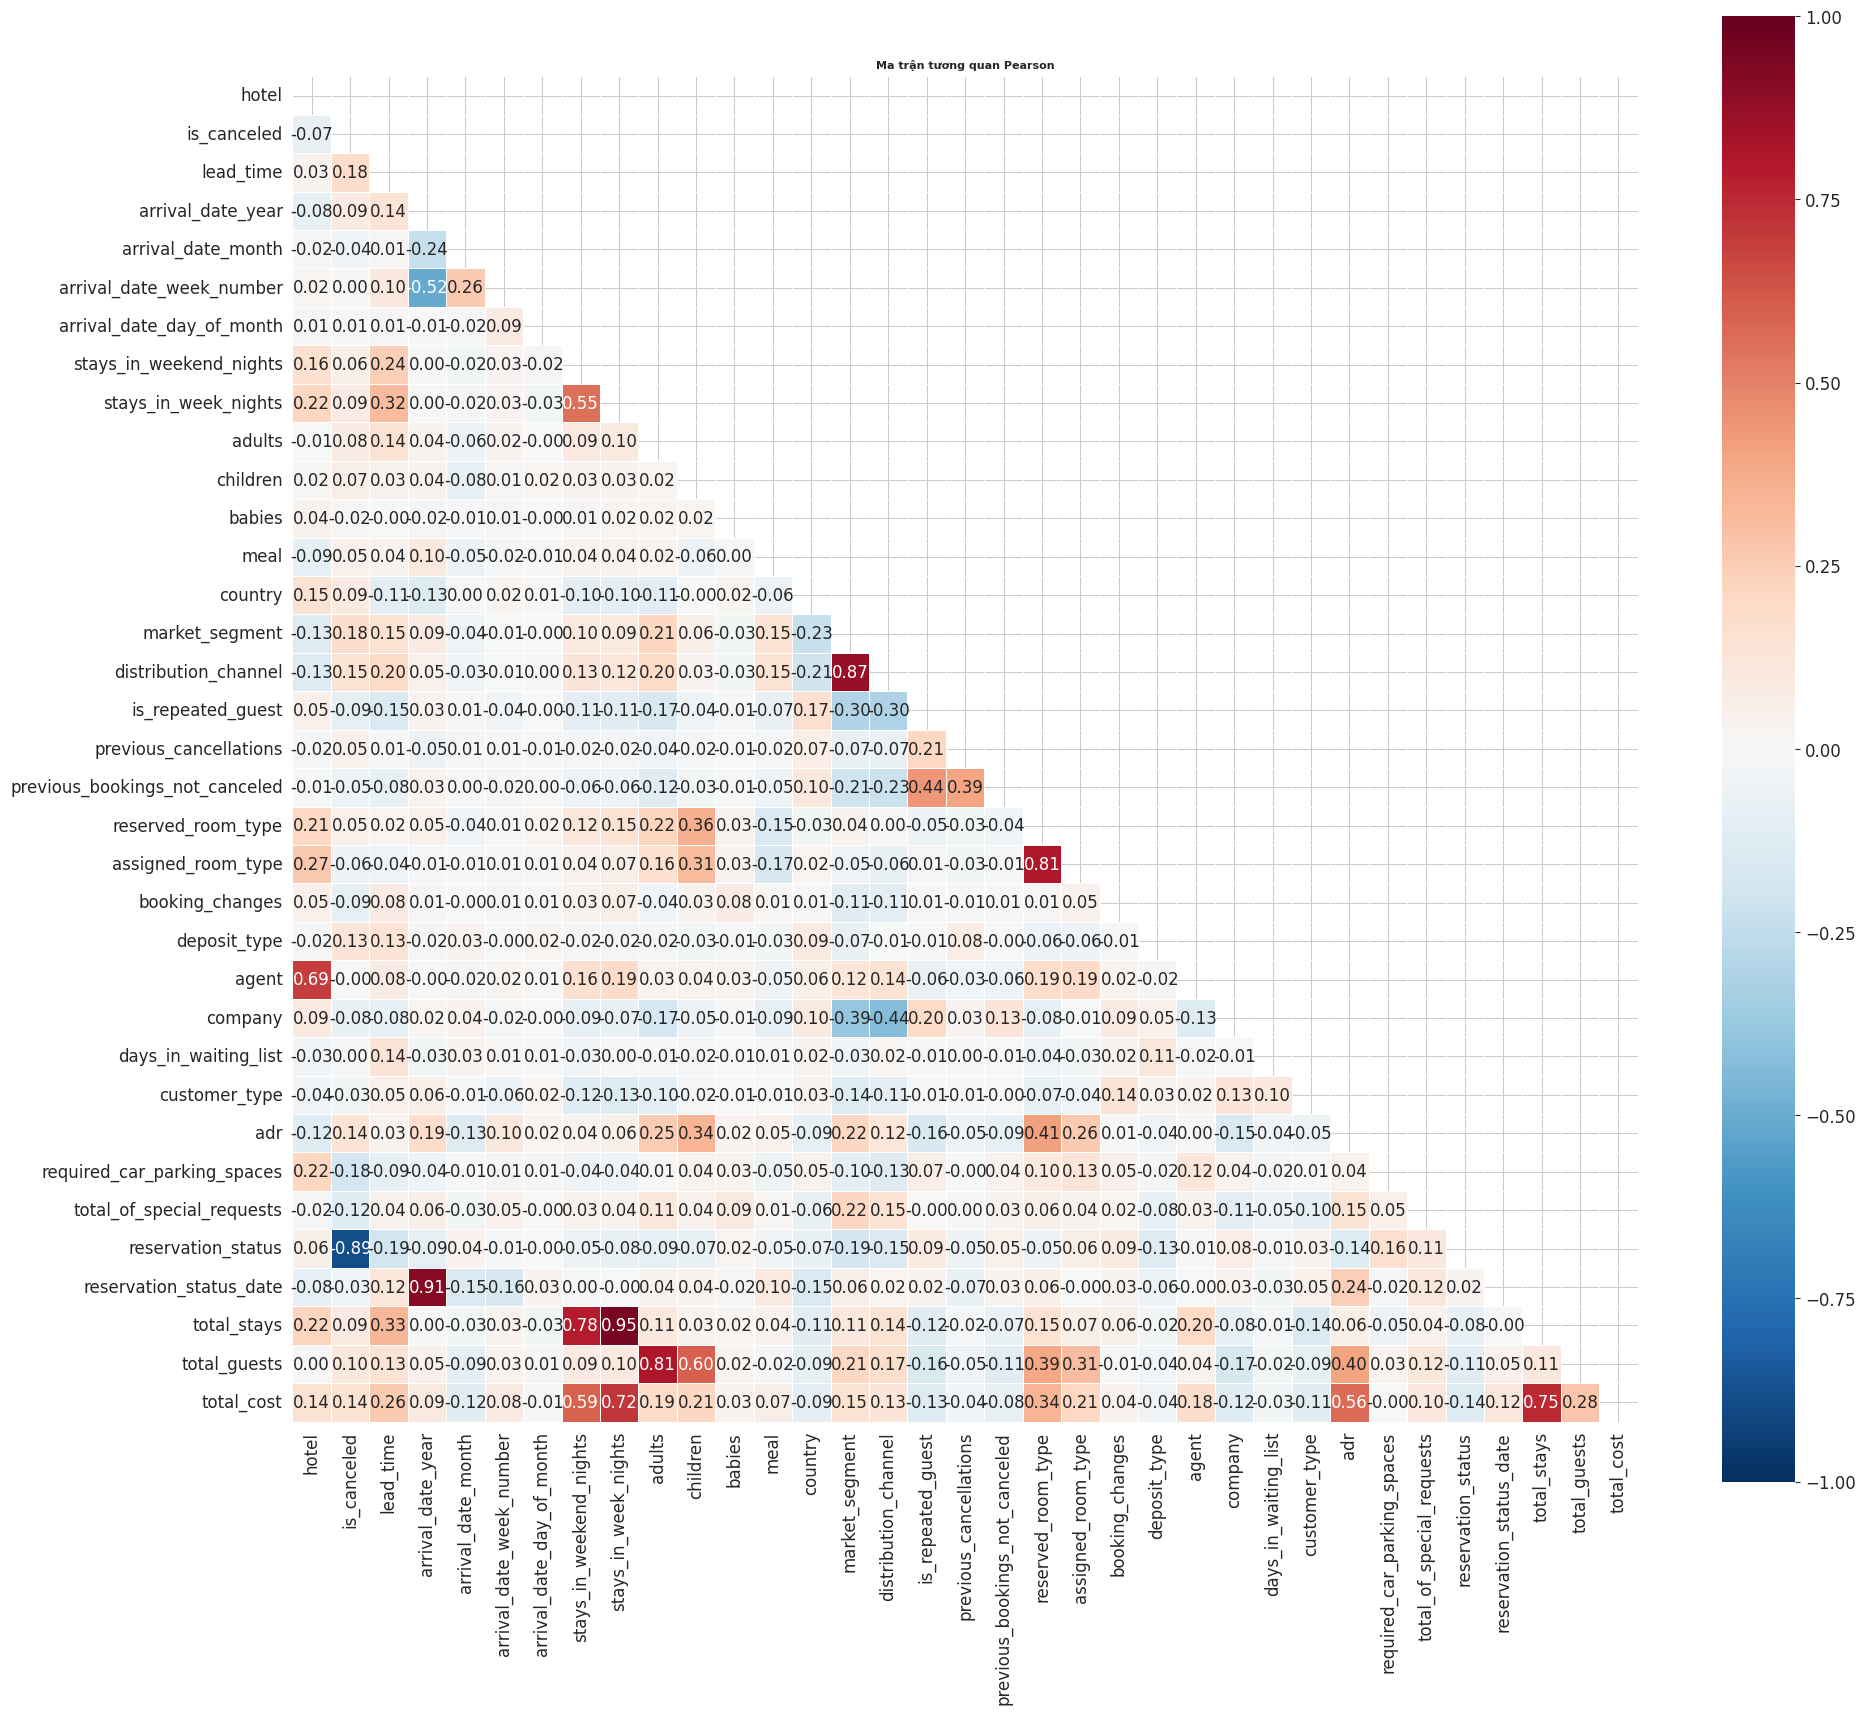

In [ ]:
# Heatmap tương quan Pearson
# Đảm bảo num_cols_updated là duy nhất để tránh cột trùng lặp 'is_canceled'
unique_num_cols_updated = list(pd.Series(num_cols_updated).drop_duplicates())
corr_df = df_encoded[unique_num_cols_updated].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(20, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận tương quan Pearson', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

1. Quy ước màu sắc trong code: Màu đỏ biểu thị tương quan dương và màu xanh biểu thị tương quan âm

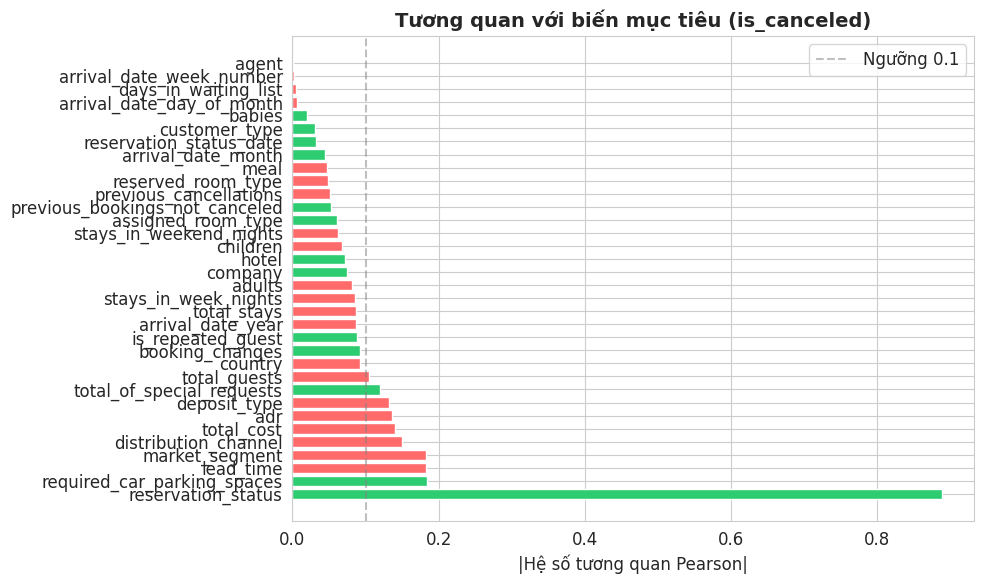

Top 10 features tương quan mạnh nhất với is_canceled:
reservation_status             0.888382
required_car_parking_spaces    0.184125
lead_time                      0.183070
market_segment                 0.182814
distribution_channel           0.149772
total_cost                     0.140908
adr                            0.135989
deposit_type                   0.131943
total_of_special_requests      0.119325
total_guests                   0.104227
Name: is_canceled, dtype: float64


In [ ]:
# Top features tương quan với is_canceled
target_corr = corr_matrix['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#ff6b6b' if v > 0 else '#2ecc71'
          for v in corr_matrix['is_canceled'].drop('is_canceled')[target_corr.index]]

plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.title('Tương quan với biến mục tiêu (is_canceled)', fontsize=14, fontweight='bold')
plt.xlabel('|Hệ số tương quan Pearson|')
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng 0.1')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features tương quan mạnh nhất với is_canceled:')
print(target_corr.head(10))

### 3.2 Trực quan hóa (Visualization)

- dữ liệu đang bị lệch chút giữa City và Resort có thể dùng phương pháp đánh trọng số để model train không bị lệch

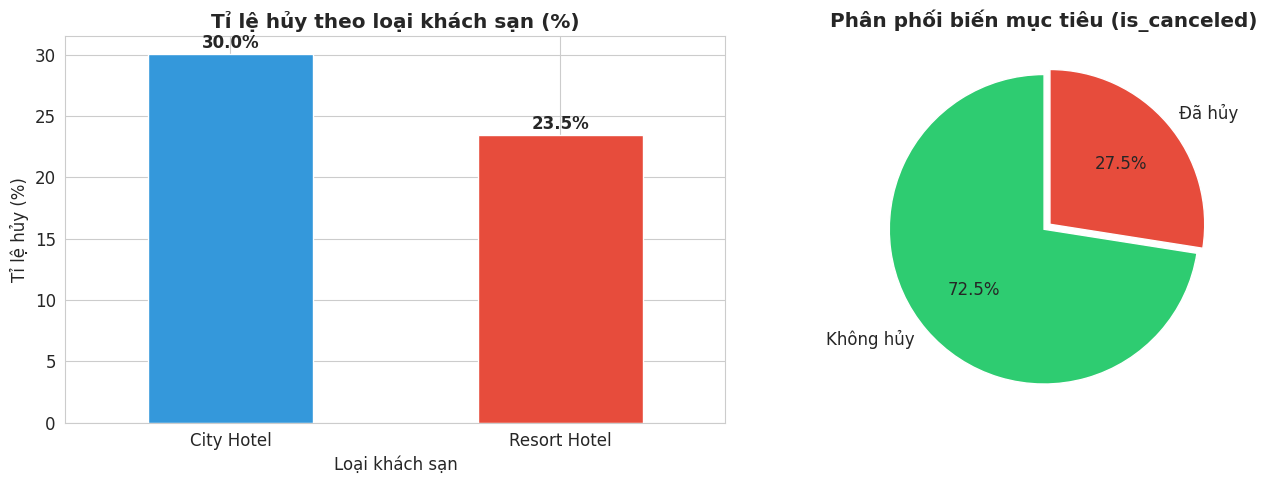

In [ ]:
# 1. Tỉ lệ hủy theo loại khách sạn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_hotel = df_clean.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Tỉ lệ hủy theo loại khách sạn (%)', fontweight='bold')
axes[0].set_xlabel('Loại khách sạn')
axes[0].set_ylabel('Tỉ lệ hủy (%)')
axes[0].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[0].patches, cancel_by_hotel):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# 2. Phân phối is_canceled
cancel_counts = df_clean['is_canceled'].value_counts()
axes[1].pie(cancel_counts.values,
            labels=['Không hủy', 'Đã hủy'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Phân phối biến mục tiêu (is_canceled)', fontweight='bold')

plt.tight_layout()
plt.show()

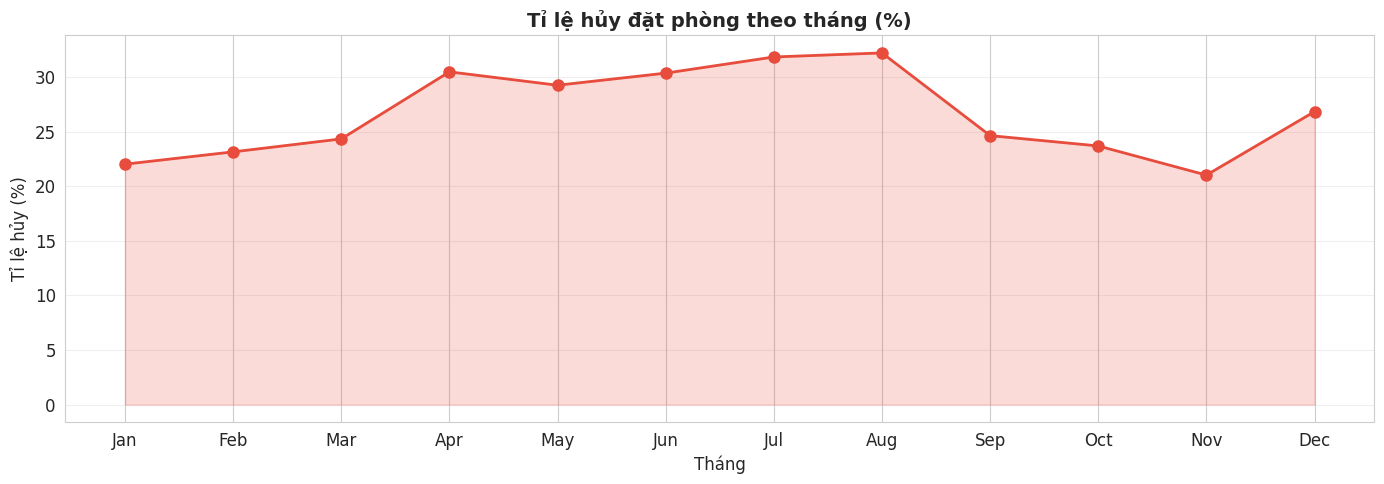

In [ ]:
# 2. Tỉ lệ hủy theo tháng
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

cancel_by_month = df_clean.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_by_month = cancel_by_month.reindex(month_order)

plt.figure(figsize=(14, 5))
plt.plot(cancel_by_month.index, cancel_by_month.values,
         marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.fill_between(range(len(cancel_by_month)), cancel_by_month.values, alpha=0.2, color='#e74c3c')
plt.xticks(range(len(month_order)), [m[:3] for m in month_order])
plt.title('Tỉ lệ hủy đặt phòng theo tháng (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Tỉ lệ hủy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

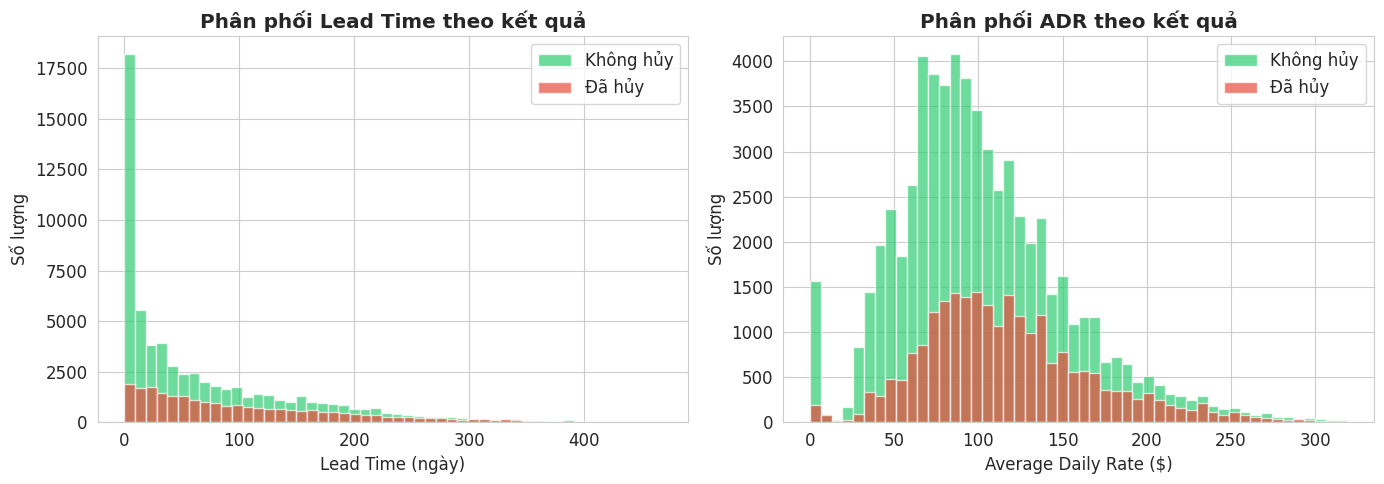

In [ ]:
# 3. Lead time vs Cancellation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lead_time by cancellation
df_clean[df_clean['is_canceled'] == 0]['lead_time'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#2ecc71', label='Không hủy')
df_clean[df_clean['is_canceled'] == 1]['lead_time'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#e74c3c', label='Đã hủy')
axes[0].set_title('Phân phối Lead Time theo kết quả', fontweight='bold')
axes[0].set_xlabel('Lead Time (ngày)')
axes[0].set_ylabel('Số lượng')
axes[0].legend()

# ADR distribution
df_clean[df_clean['is_canceled'] == 0]['adr'].hist(
    ax=axes[1], bins=50, alpha=0.7, color='#2ecc71', label='Không hủy')
df_clean[df_clean['is_canceled'] == 1]['adr'].hist(
    ax=axes[1], bins=50, alpha=0.7, color='#e74c3c', label='Đã hủy')
axes[1].set_title('Phân phối ADR theo kết quả', fontweight='bold')
axes[1].set_xlabel('Average Daily Rate ($)')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

Khách hàng đặt phòng càng xa ngày đi du lịch thì xác suất họ hủy phòng càng cao

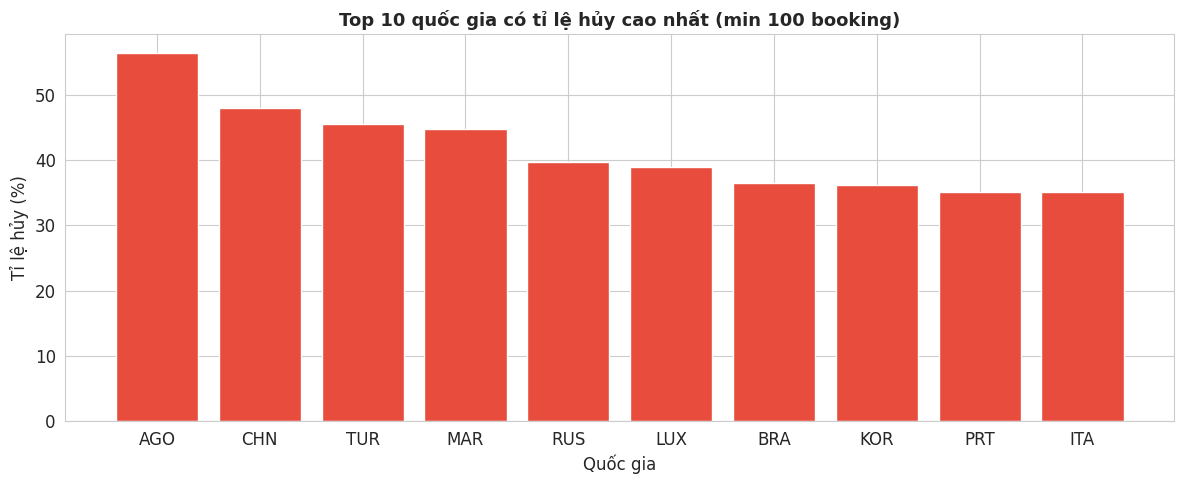

In [ ]:
# 4. Top 10 quốc gia có tỉ lệ hủy cao nhất
country_cancel = df_clean.groupby('country').agg(
    total=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum')
).reset_index()
country_cancel['cancel_rate'] = country_cancel['canceled'] / country_cancel['total'] * 100
country_cancel = country_cancel[country_cancel['total'] > 100]  # chỉ lấy nước có >100 booking
top10 = country_cancel.nlargest(10, 'cancel_rate')

plt.figure(figsize=(12, 5))
plt.bar(top10['country'], top10['cancel_rate'], color='#e74c3c', edgecolor='white')
plt.title('Top 10 quốc gia có tỉ lệ hủy cao nhất (min 100 booking)', fontsize=13, fontweight='bold')
plt.xlabel('Quốc gia')
plt.ylabel('Tỉ lệ hủy (%)')
plt.tight_layout()
plt.show()

---
## 4. Huấn luyện mô hình
### 4.1 & Random Forest

In [ ]:
# Huấn luyện Random Forest với cơ chế phạt mất cân bằng lớp

if 'results' not in locals() and 'results' not in globals():
    results = {}

# THÊM THAM SỐ class_weight='balanced' Ở ĐÂY
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_np, y_train)
rf_pred = rf.predict(X_val_np)
rf_proba = rf.predict_proba(X_val_np)[:, 1]

results['Random Forest'] = {
    'accuracy': accuracy_score(y_val, rf_pred),
    'f1': f1_score(y_val, rf_pred),
    'auc': roc_auc_score(y_val, rf_proba)
}
print(f'  Accuracy: {results["Random Forest"]["accuracy"]:.4f}')
print(f'  F1 Score: {results["Random Forest"]["f1"]:.4f}')
print(f'  ROC-AUC:  {results["Random Forest"]["auc"]:.4f}')

# Feature importance từ Random Forest
rf_feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 10 features quan trọng nhất (Random Forest):')
print(rf_feat_imp.head(10).to_string(index=False))

Huấn luyện Random Forest (Có cơ chế phạt)...
  Accuracy: 0.8474
  F1 Score: 0.6952
  ROC-AUC:  0.9028

Top 10 features quan trọng nhất (Random Forest):
                    Feature  Importance
                  lead_time    0.128326
                    country    0.112720
                        adr    0.072438
                 total_cost    0.070101
                      agent    0.058281
  arrival_date_day_of_month    0.054916
   arrival_date_week_number    0.053514
             market_segment    0.053403
  total_of_special_requests    0.049352
required_car_parking_spaces    0.045971


### 4.2 TabNet — Main Model

In [ ]:
# chuan bi categorical dimensions cho TabNet
cat_cols_in_X = [c for c in cat_cols if c in X.columns]
cat_idxs = [list(X.columns).index(c) for c in cat_cols_in_X]
cat_dims = [int(df_encoded[c].nunique()) + 1 for c in cat_cols_in_X]
print(f'Số cột categorical cho TabNet: {len(cat_idxs)}')
print(f'Cat dims: {cat_dims}')

Số cột categorical cho TabNet: 0
Cat dims: []


-Tự động đếm và lưu lại thông tin cấu hình của các cột chữ (categorical) để khai báo trực tiếp cho cấu trúc mạng nơ-ron TabNet.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.7 MB/s eta 0:00:00


1. Sử dụng thư viện Optuna để tự động chạy thử nghiệm và tìm ra bộ siêu tham số (Hyperparameters) tối ưu nhất cho mô hình TabNet.
2. Thuật toán sẽ tự động dò tìm trong không gian thiết lập để chọn ra tổ hợp tốt nhất cho các tham số như độ rộng mạng (n_d), số bước chú ý (n_steps), tốc độ học (lr) và hệ số phạt (gamma).
3. Kết quả đầu ra: Sau khi chạy xong 10 lượt thử (n_trials=10), lệnh study.best_params sẽ in ra bộ thông số "vàng" giúp mô hình đạt hiệu năng dự báo hủy phòng cao nhất để đem đi huấn luyện chính thức.

In [ ]:

import optuna
import logging
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
optuna.logging.set_verbosity(optuna.logging.WARNING)
device = "cuda" if torch.cuda.is_available() else "cpu"

def objective(trial):

    cat_idxs = [i for i, f in enumerate(feature_cols) if f in cat_cols]
    cat_dims = [df_encoded[f].nunique() for f in feature_cols if f in cat_cols]


    cat_emb_dim = []
    for dim in cat_dims:
        emb_dim = trial.suggest_int(f'emb_dim_{dim}', 1, min(50, (dim + 1) // 2))
        cat_emb_dim.append(emb_dim)


    n_d = trial.suggest_int('n_d', 8, 64, step=8)
    n_steps = trial.suggest_int('n_steps', 3, 7)


    lr = trial.suggest_float('lr', 1e-3, 5e-2, log=True)
    gamma = trial.suggest_float('gamma', 1.0, 1.8, step=0.1)


    lambda_sparse = trial.suggest_float('lambda_sparse', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)


    batch_size = trial.suggest_categorical('batch_size', [1024, 2048, 4096])
    virtual_batch_size = trial.suggest_categorical('virtual_batch_size', [128, 256])


    model = TabNetClassifier(
        cat_idxs=cat_idxs,
        cat_dims=cat_dims,
        cat_emb_dim=cat_emb_dim,
        n_d=n_d,
        n_a=n_d,
        n_steps=n_steps,
        gamma=gamma,
        lambda_sparse=lambda_sparse,
        mask_type='sparsemax',
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=lr, weight_decay=weight_decay),
        device_name=device
    )


    model.fit(
        X_train=X_train_np, y_train=y_train,
        eval_set=[(X_train_np, y_train), (X_val_np, y_val)],
        eval_name=['train', 'valid'],
        eval_metric=['auc'],
        max_epochs=50,
        patience=10,
        batch_size=batch_size,
        virtual_batch_size=virtual_batch_size,
        weights=sample_weights
    )


    best_val_auc = max(model.history['valid_auc'])
    return best_val_auc

1. Cơ chế Chú ý thưa thớt (Sparse Attention & Sequential Attention)
2. Khả năng tự giải thích (Explainability)

- dùng cơ chế đánh trọng số nếu đánh trọng số càng nặng thì FP càng lớn, accuracy càng nhỏ nên để đánh trọng số nhẹ

In [ ]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd


hotel_idx = feature_cols.index('hotel')
hotel_train_data = X_train_np[:, hotel_idx]
train_combined = pd.Series(hotel_train_data.astype(str)) + "_" + pd.Series(y_train.astype(str))

subgroup_classes = np.unique(train_combined)
weight_dict = compute_class_weight(
    class_weight='balanced',
    classes=subgroup_classes,
    y=train_combined
)
weight_dict = dict(zip(subgroup_classes, weight_dict))


light_weight_dict = {k: np.log1p(v) + 0.5 for k, v in weight_dict.items()}
sample_weights = train_combined.map(light_weight_dict).values

print("Đã cập nhật TRỌNG SỐ PHẠT GIẢM NHẸ (Light Weights) cho tập Train:")
for k, v in light_weight_dict.items():
    print(f" - Nhóm {k} (Gốc: {weight_dict[k]:.4f}) -> Phạt nhẹ đi còn: {v:.4f}")


best_params = study.best_params

tabnet_model = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=cat_emb_dim,
    n_d=best_params['n_d'],
    n_a=best_params['n_d'],
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    lambda_sparse=best_params.get('lambda_sparse', 1e-3),
    mask_type='sparsemax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(
        lr=best_params['lr'],
        weight_decay=best_params.get('weight_decay', 1e-5)
    ),
    device_name=device
)


tabnet_model.fit(
    X_train=X_train_np, y_train=y_train,
    eval_set=[(X_train_np, y_train), (X_val_np, y_val)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=15,
    batch_size=best_params.get('batch_size', 2048),
    virtual_batch_size=best_params.get('virtual_batch_size', 256),
    weights=sample_weights # Truyền bộ trọng số đã được ép nhỏ
)

Đã cập nhật TRỌNG SỐ PHẠT GIẢM NHẸ (Light Weights) cho tập Train:
 - Nhóm 0.0_0 (Gốc: 0.5838) -> Phạt nhẹ đi còn: 0.9598
 - Nhóm 0.0_1 (Gốc: 1.3641) -> Phạt nhẹ đi còn: 1.3604
 - Nhóm 1.0_0 (Gốc: 0.8418) -> Phạt nhẹ đi còn: 1.1107
 - Nhóm 1.0_1 (Gốc: 2.7314) -> Phạt nhẹ đi còn: 1.8168
epoch 0  | loss: 0.69822 | train_auc: 0.54746 | valid_auc: 0.548   |  0:00:04s
epoch 1  | loss: 0.54698 | train_auc: 0.56312 | valid_auc: 0.55226 |  0:00:09s
epoch 2  | loss: 0.5143  | train_auc: 0.53096 | valid_auc: 0.5207  |  0:00:15s
epoch 3  | loss: 0.50742 | train_auc: 0.6705  | valid_auc: 0.66389 |  0:00:19s
epoch 4  | loss: 0.50575 | train_auc: 0.64307 | valid_auc: 0.63247 |  0:00:22s
epoch 5  | loss: 0.4952  | train_auc: 0.72628 | valid_auc: 0.71742 |  0:00:27s
epoch 6  | loss: 0.48541 | train_auc: 0.63457 | valid_auc: 0.62388 |  0:00:32s
epoch 7  | loss: 0.48513 | train_auc: 0.7001  | valid_auc: 0.68746 |  0:00:34s
epoch 8  | loss: 0.48926 | train_auc: 0.74417 | valid_auc: 0.73621 |  0:00:36s
epo

In [ ]:
tabnet_pred = tabnet_model.predict(X_val_np)
tabnet_proba = tabnet_model.predict_proba(X_val_np)[:, 1]

results['TabNet'] = {
    'accuracy': accuracy_score(y_val, tabnet_pred),
    'f1': f1_score(y_val, tabnet_pred),
    'auc': roc_auc_score(y_val, tabnet_proba)
}
print(f'TabNet - Validation Set:')
print(f'  Accuracy: {results["TabNet"]["accuracy"]:.4f}')
print(f'  F1 Score: {results["TabNet"]["f1"]:.4f}')
print(f'  ROC-AUC:  {results["TabNet"]["auc"]:.4f}')

TabNet - Validation Set:
  Accuracy: 0.8256
  F1 Score: 0.6999
  ROC-AUC:  0.8942


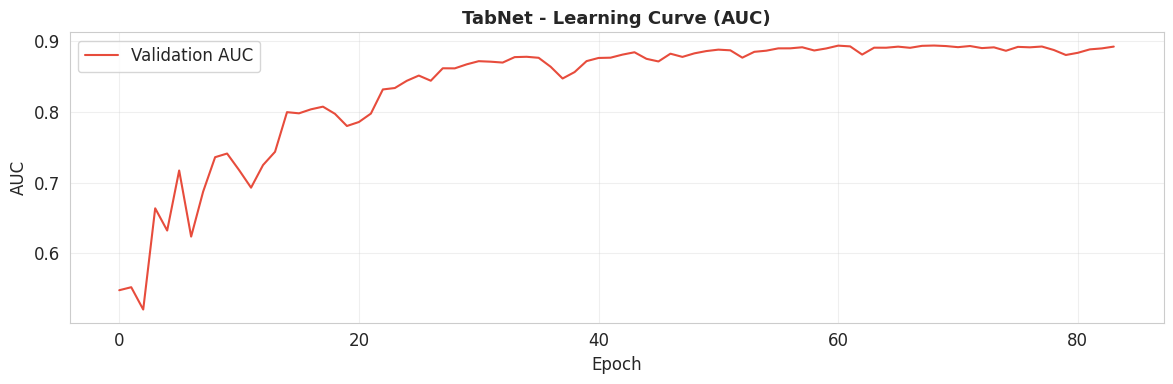

In [ ]:
# Vẽ learning curve của TabNet
plt.figure(figsize=(12, 4))
plt.plot(tabnet_model.history['valid_auc'], label='Validation AUC', color='#e74c3c')
plt.title('TabNet - Learning Curve (AUC)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Đánh giá & Phân tích kết quả
### 5.1 So sánh các mô hình

In [ ]:
# Bảng so sánh
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'F1 Score', 'ROC-AUC']
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('So sánh các mô hình trên Validation Set:')
print(results_df.to_string(index=False))

So sánh các mô hình trên Validation Set:
        Model  Accuracy  F1 Score  ROC-AUC
Random Forest  0.847363  0.695240 0.902753
       TabNet  0.825590  0.699908 0.894190


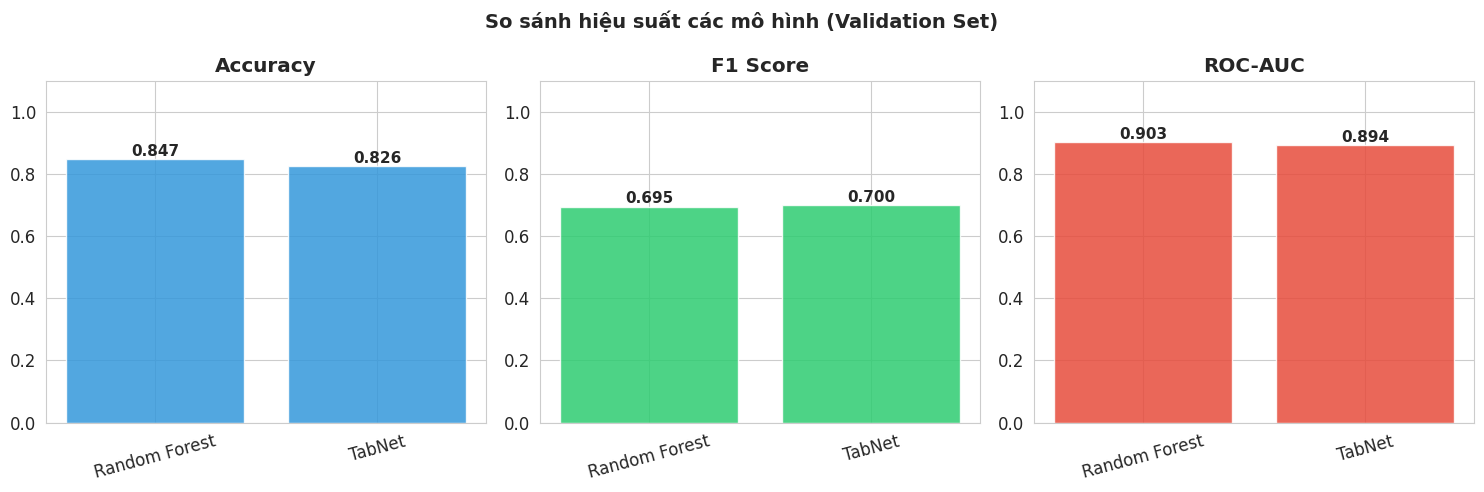

In [ ]:
# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('So sánh hiệu suất các mô hình (Validation Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 ROC Curve

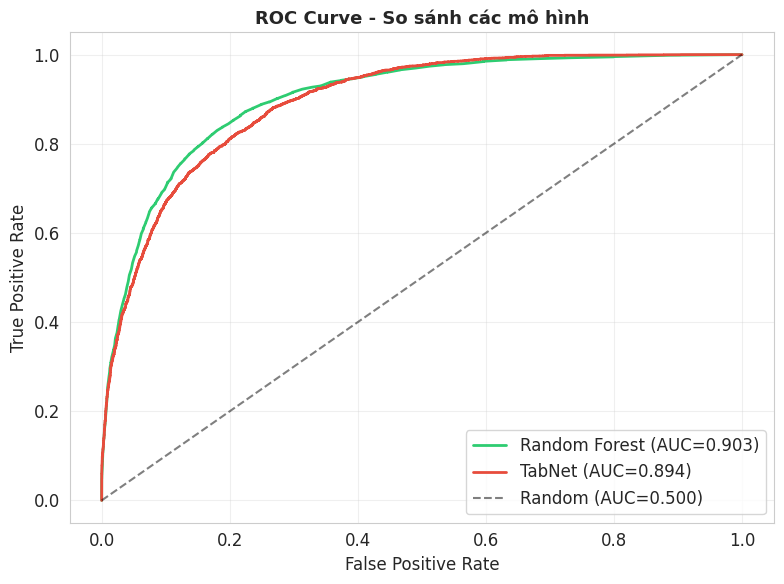

In [ ]:
# ROC Curve cho tất cả mô hình
plt.figure(figsize=(8, 6))

for (name, proba), color in zip(
    [
     ('Random Forest', rf_proba),
     ('TabNet', tabnet_proba)
    ],
    ['#2ecc71', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - So sánh các mô hình', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix

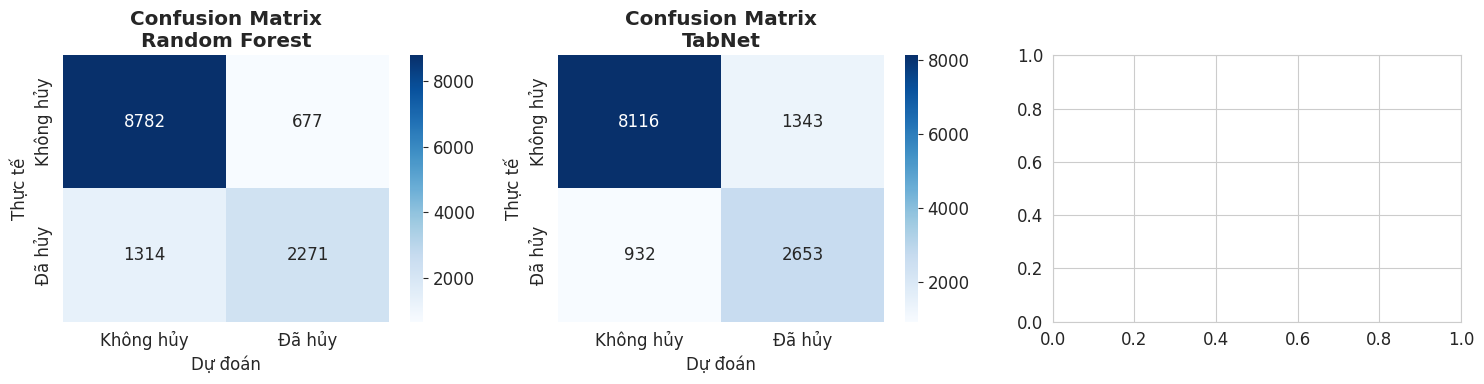

In [ ]:
# Confusion Matrix cho TabNet
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [

    ('Random Forest', rf_pred),
    ('TabNet', tabnet_pred)
]):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Không hủy', 'Đã hủy'],
                yticklabels=['Không hủy', 'Đã hủy'])
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax.set_ylabel('Thực tế')
    ax.set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()

### 5.4 Feature Importance từ TabNet (Attention Mask)

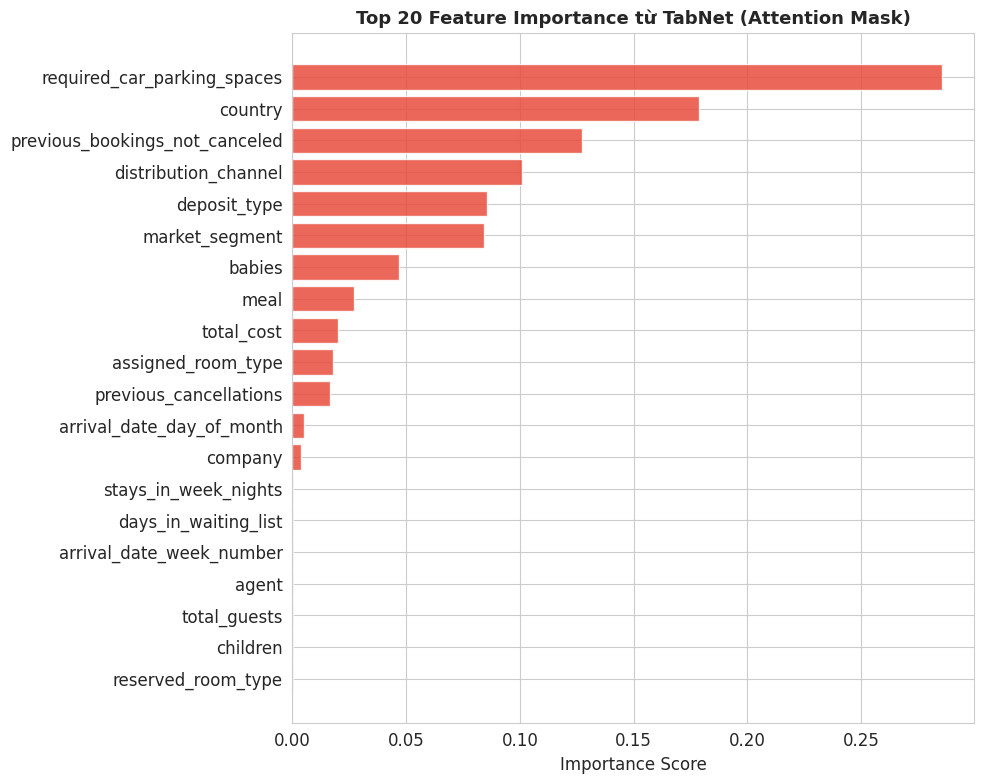

Top 10 features quan trọng nhất:
                       Feature  Importance
   required_car_parking_spaces    0.285419
                       country    0.178897
previous_bookings_not_canceled    0.127267
          distribution_channel    0.100941
                  deposit_type    0.085434
                market_segment    0.084379
                        babies    0.046679
                          meal    0.026942
                    total_cost    0.020138
            assigned_room_type    0.017849


In [ ]:
# Feature importance từ TabNet attention
feature_importances = tabnet_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': list(X.columns),
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Top 20 features
top_feat = feat_imp_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_feat['Feature'][::-1], top_feat['Importance'][::-1],
         color='#e74c3c', alpha=0.85, edgecolor='white')
plt.title('Top 20 Feature Importance từ TabNet (Attention Mask)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features quan trọng nhất:')
print(feat_imp_df.head(10).to_string(index=False))

### 5.5 Đánh giá trên Test Set (Final)

In [ ]:
# Đánh giá TabNet trên test set
test_pred = tabnet_model.predict(X_test_np)
test_proba = tabnet_model.predict_proba(X_test_np)[:, 1]

print('=' * 50)
print('KẾT QUẢ CUỐI CÙNG - TabNet trên Test Set')
print('=' * 50)
print(f'Accuracy: {accuracy_score(y_test, test_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, test_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, test_proba):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, test_pred,
      target_names=['Không hủy', 'Đã hủy']))

KẾT QUẢ CUỐI CÙNG - TabNet trên Test Set
Accuracy: 0.8263
F1 Score: 0.6973
ROC-AUC:  0.8938

Classification Report:
              precision    recall  f1-score   support

   Không hủy       0.89      0.86      0.88      9458
      Đã hủy       0.67      0.73      0.70      3584

    accuracy                           0.83     13042
   macro avg       0.78      0.80      0.79     13042
weighted avg       0.83      0.83      0.83     13042



### 5.6 phân tích kết quả

In [ ]:
# DỰ ĐOÁN & IN KẾT QUẢ TEST SET ---
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

test_pred = tabnet_model.predict(X_test_np)
test_proba = tabnet_model.predict_proba(X_test_np)[:, 1]


final_results = {

    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf.predict(X_test_np)),
        'F1 Score': f1_score(y_test, rf.predict(X_test_np)),
        'ROC-AUC': roc_auc_score(y_test, rf.predict_proba(X_test_np)[:, 1])
    },
    'TabNet (Improved)': {
        'Accuracy': accuracy_score(y_test, test_pred),
        'F1 Score': f1_score(y_test, test_pred),
        'ROC-AUC': roc_auc_score(y_test, test_proba)
    }
}

final_df = pd.DataFrame(final_results).T
print(final_df.round(4).to_string())

                   Accuracy  F1 Score  ROC-AUC
Random Forest        0.8457    0.6909   0.9052
TabNet (Improved)    0.8263    0.6973   0.8938


1. TABNET VỚI CẤU TRÚC DNN:
 - Khối biến đổi chú ý (Attentive Transformer):tạo ra lớp mặt nạ( Mask ) chỉ cho các đặc tính quan trọng đi tiếp vào khối sau.
 - Khối biến đổi đặc trưng (Feature Transformer): các tính năng sau khi Masking sẽ được đưa vào đây để học các đặc trưng phi tuyến tính với 4 khối GLU.
Tabnet có cấu trúc Chọn tính tăng -> học phi tuyến tính-> phản hồi và lặp lại.
2. So sánh Tabnet với RF:
- Dựa trên kết quả Tabnet rất mạnh với khả năng học phi tuyến tính và mạnh gần ngang với RF chênh nhau không quá 5%.
- khả năng lọc nhiễu của Tabnet với hàm sparsemax sẽ đánh trọng số của các biến rác về bằng 0 , trong khi xác xuất Rf chọn vào biến rác là rất cao khi số lượng rác quá lớn.
- Về khả năng giải tích, Tabnet có thể giải thích trên từng dòng dữ liệu (Instance-level interpretability) với cơ chế mặt nạ (Mask), còn RF chỉ cho biết biến nào quan trọng trên toàn bộ tập dữ liệu,
- Khả năng dùng GPU: Tabnet có lợi thế dùng được GPU để train đây là điểm yếu của RF và các mô hình cũ Scikit-learn.
- --> Nếu bộ dữ liệu lơn hơn và phức tạp hơn thì Tabnet sẽ phát huy được tối đa khả năng chọn lọc đặc trưng để học phi tuyến tính.



